# **Part-2 Vision Task**

**1. Imports**

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

2026-05-14 08:42:10.475539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778748130.717729      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778748130.795242      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778748131.340227      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778748131.340265      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778748131.340268      57 computation_placer.cc:177] computation placer alr

**2. Check GPU**

In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**3. Dataset Paths**

In [3]:
import os
DATASET_ROOT = "/kaggle/input/datasets/shreeyamaskey01/plant-diseases-classification-dataset"

train_dir = os.path.join(DATASET_ROOT,"train","train")

val_dir = os.path.join(DATASET_ROOT,"val","val")

test_dir = os.path.join(DATASET_ROOT,"test","test")

**4. Smaller Image Size + Lower Batch**

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

**5. Load Dataset**

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 67507 files belonging to 38 classes.


I0000 00:00:1778748200.824939      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778748200.831183      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 25364 files belonging to 38 classes.
Found 17216 files belonging to 38 classes.


**6. Dataset Optimization**

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(500).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

**8. Display Sample Images**

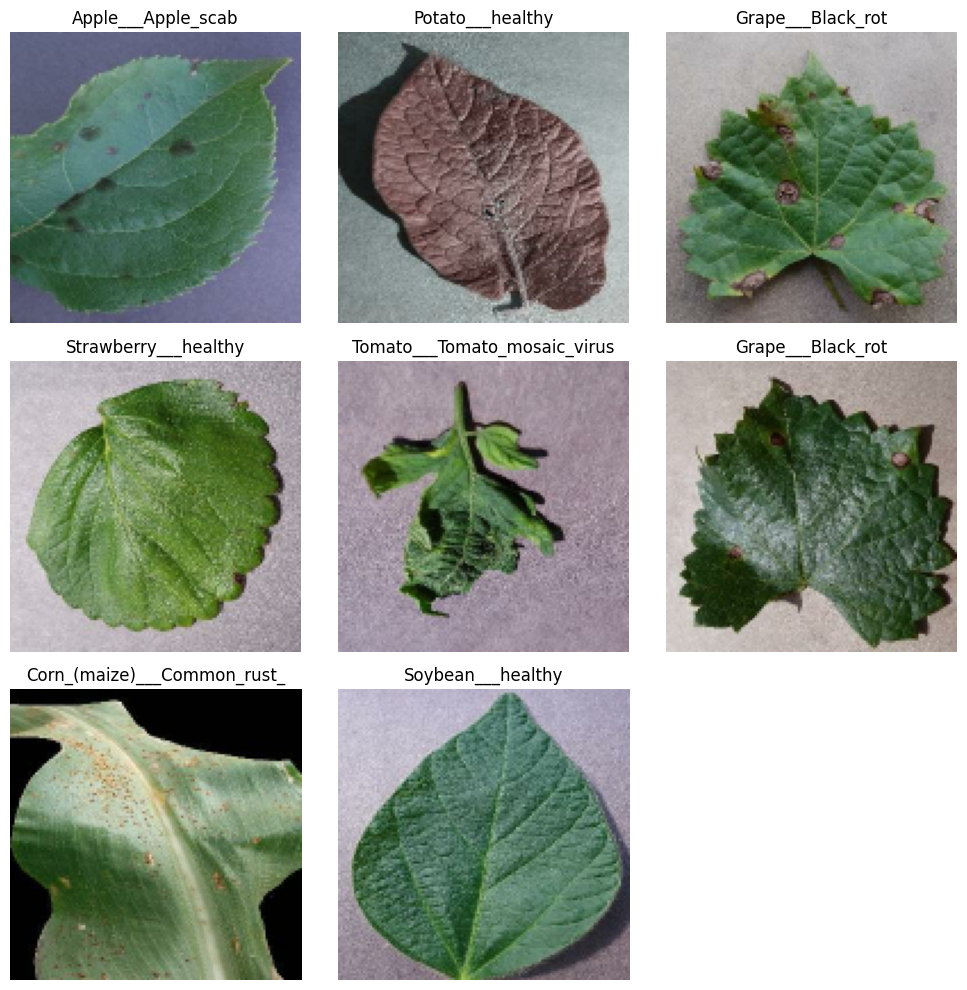

In [7]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    batch_size_actual = len(images)

    for i in range(min(9, batch_size_actual)):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

**PART A — BASELINE CNN**

**9. Build Baseline CNN Model**

In [8]:
baseline_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(150,150,3)),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')

])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,806 (143.77 KB)

 Trainable params: 36,806 (143.77 KB)

 Non-trainable params: 0 (0.00 B)

**10. Compile Baseline CNN**

In [9]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**11. Early Stopping**

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**12. Train Baseline CNN**

In [11]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

baseline_training_time = time.time() - start_time

print("Baseline Training Time:", baseline_training_time)

Epoch 1/10


I0000 00:00:1778748225.958195     179 service.cc:152] XLA service 0x780db80314e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778748225.958240     179 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778748225.958245     179 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778748226.337594     179 cuda_dnn.cc:529] Loaded cuDNN version 91002


  33/8439 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.0401 - loss: 3.6414      

I0000 00:00:1778748229.285407     179 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8439/8439 ━━━━━━━━━━━━━━━━━━━━ 104s 12ms/step - accuracy: 0.3219 - loss: 2.3674 - val_accuracy: 0.7277 - val_loss: 0.8938
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - accuracy: 0.7520 - loss: 0.7848 - val_accuracy: 0.8513 - val_loss: 0.4900
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - accuracy: 0.8348 - loss: 0.5157 - val_accuracy: 0.8730 - val_loss: 0.4035
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - accuracy: 0.8717 - loss: 0.3957 - val_accuracy: 0.8903 - val_loss: 0.3274
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 52s 6ms/step - accuracy: 0.8928 - loss: 0.3274 - val_accuracy: 0.9037 - val_loss: 0.2947
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - accuracy: 0.9074 - loss: 0.2790 - val_accuracy: 0.9207 - val_loss: 0.2429
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - accuracy: 0.9210 - loss: 0.2441 - val_accuracy: 0.9239 - val_loss: 0.2374
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - accuracy: 0.9233 - loss: 0.2308 - v

**13. Plot Baseline CNN Accuracy**

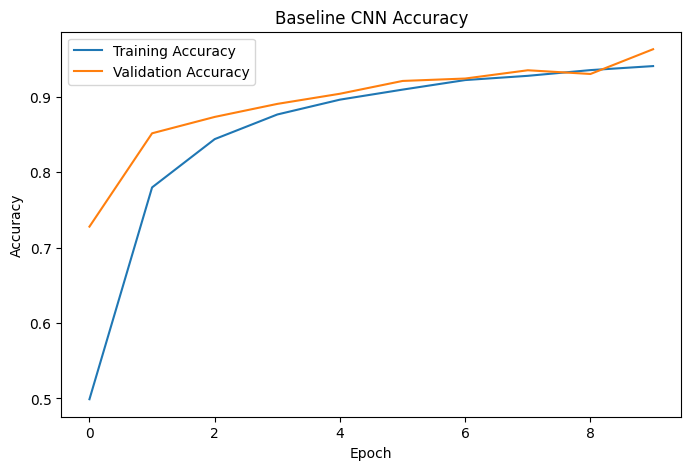

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')

plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

**14.Plot Baseline CNN Loss**

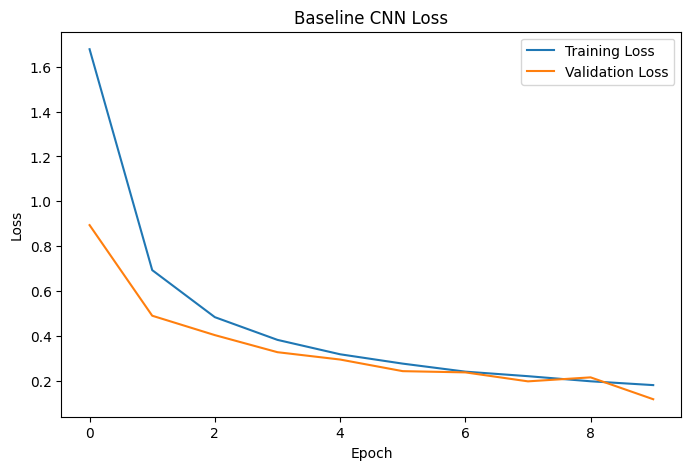

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='Training Loss')

plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.title("Baseline CNN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**PART B —DEEP CNN**

**15. Build Deep CNN Model**

In [14]:
deep_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(150,150,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')

])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,222 (1.81 MB)

 Trainable params: 473,222 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

**16. Compile Deep CNN**

In [15]:
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**17. Train Deep CNN**

In [16]:
start_time = time.time()

history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

deep_training_time = time.time() - start_time

print("Deep CNN Training Time:", deep_training_time)

Epoch 1/10


2026-05-14 08:53:22.962372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:53:23.100878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


7992/8439 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1807 - loss: 2.9196

2026-05-14 08:54:39.003176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 08:54:39.140979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8439/8439 ━━━━━━━━━━━━━━━━━━━━ 101s 11ms/step - accuracy: 0.1911 - loss: 2.8774 - val_accuracy: 0.7235 - val_loss: 0.8731
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.7352 - loss: 0.8419 - val_accuracy: 0.8783 - val_loss: 0.3895
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.8404 - loss: 0.5033 - val_accuracy: 0.9287 - val_loss: 0.2276
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.8876 - loss: 0.3587 - val_accuracy: 0.9424 - val_loss: 0.1841
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.9096 - loss: 0.2851 - val_accuracy: 0.9467 - val_loss: 0.1635
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 92s 11ms/step - accuracy: 0.9289 - loss: 0.2251 - val_accuracy: 0.9497 - val_loss: 0.1541
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.9361 - loss: 0.2037 - val_accuracy: 0.9669 - val_loss: 0.1018
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 96s 11ms/step - accuracy: 0.9449 - loss: 0.1

**18. Plot Deep CNN Accuracy**

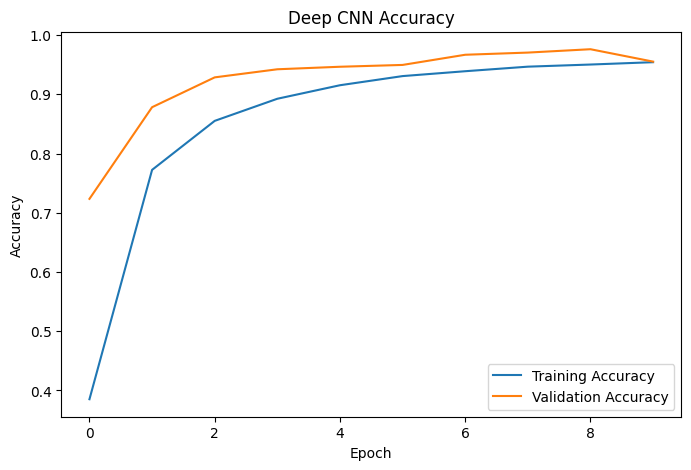

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['accuracy'], label='Training Accuracy')

plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')

plt.title("Deep CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

**19.Plot Deep CNN Loss**

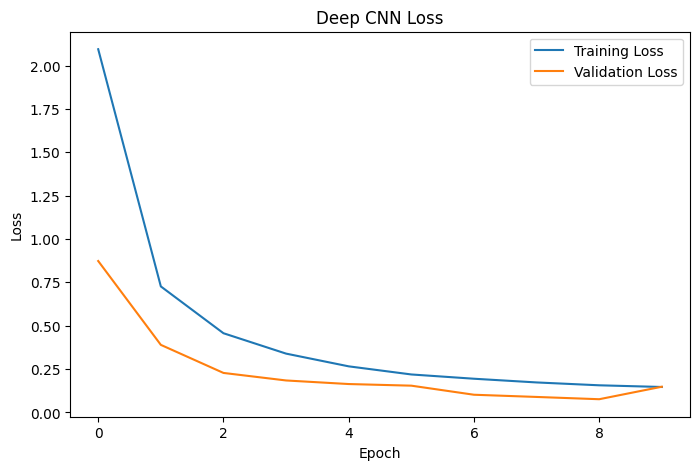

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['loss'], label='Training Loss')

plt.plot(history_deep.history['val_loss'], label='Validation Loss')

plt.title("Deep CNN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**PART C — TRANSFER LEARNING USING VGG16**

**20. Load Pretrained VGG16 Model**

In [19]:
base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(128,128,3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**21. Build VGG16 Model**

In [20]:
vgg_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(128,128,3)),

    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')

])

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,821,862 (64.17 MB)

 Trainable params: 2,107,174 (8.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**22. Compile VGG16 Model**

In [21]:
vgg_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

**23. Train model**

In [22]:
start_time = time.time()

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

vgg_training_time = time.time() - start_time

print("VGG16 Training Time:", vgg_training_time)

Epoch 1/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 231s 27ms/step - accuracy: 0.5446 - loss: 1.6434 - val_accuracy: 0.8921 - val_loss: 0.3841
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 219s 26ms/step - accuracy: 0.8291 - loss: 0.5451 - val_accuracy: 0.9232 - val_loss: 0.2556
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 219s 26ms/step - accuracy: 0.8693 - loss: 0.4058 - val_accuracy: 0.9420 - val_loss: 0.1983
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 219s 26ms/step - accuracy: 0.8906 - loss: 0.3321 - val_accuracy: 0.9527 - val_loss: 0.1598
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 218s 26ms/step - accuracy: 0.9026 - loss: 0.2961 - val_accuracy: 0.9566 - val_loss: 0.1423
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 220s 26ms/step - accuracy: 0.9147 - loss: 0.2568 - val_accuracy: 0.9627 - val_loss: 0.1253
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 219s 26ms/step - accuracy: 0.9229 - loss: 0.2304 - val_accuracy: 0.9666 - val_loss: 0.1075
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 219s 26ms/step - accuracy: 

**24. Plot VGG16 Accuracy**

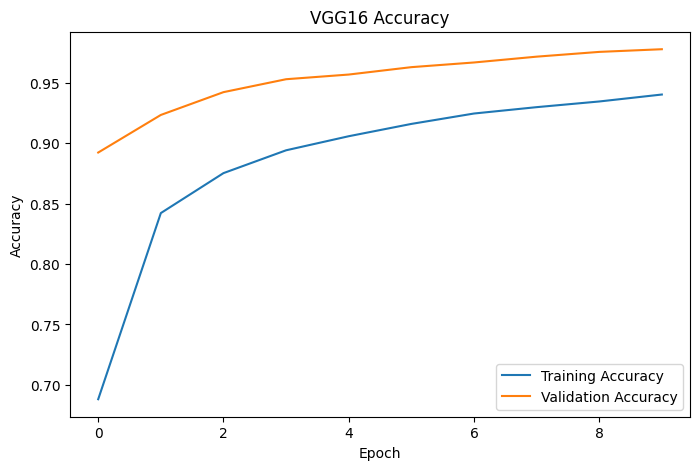

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**25. Plot VGG16 Loss**

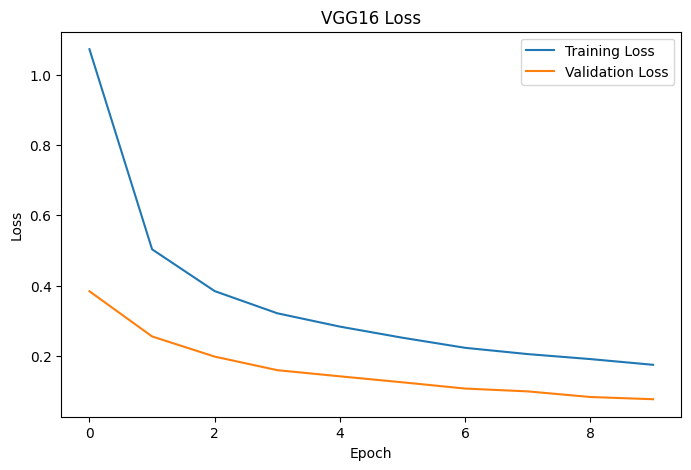

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['loss'], label='Training Loss')

plt.plot(history_vgg.history['val_loss'], label='Validation Loss')

plt.title("VGG16 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**26. Model Evaluation Function**

In [25]:
def evaluate_model(model, model_name):

    print("\n")
    print("="*50)
    print(model_name)
    print("="*50)

    y_true = np.concatenate(
        [y.numpy() for x, y in test_ds],
        axis=0
    )

    predictions = model.predict(test_ds)

    y_pred = np.argmax(predictions, axis=1)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    return y_true, y_pred

**27. Evaluate Baseline CNN**

In [26]:
baseline_true, baseline_pred = evaluate_model(
    baseline_model,
    "BASELINE CNN"
)



BASELINE CNN
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.94      0.93       504
                                 Apple___Black_rot       1.00      0.97      0.98       497
                          Apple___Cedar_apple_rust       0.58      1.00      0.74        84
                                   Apple___healthy       0.97      0.92      0.94       502
                               Blueberry___healthy       0.97      0.96      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.95      0.96      0.95       421
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.93      0.92       410
                       Corn_(maize)___Common_rust_       0.97      1.00      0.99       477
               Corn_(

**28. Evaluate Deep CNN**

In [27]:
deep_true, deep_pred = evaluate_model(
    deep_model,
    "DEEP CNN"
)



DEEP CNN
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.99      0.96       504
                                 Apple___Black_rot       0.97      1.00      0.99       497
                          Apple___Cedar_apple_rust       0.86      0.99      0.92        84
                                   Apple___healthy       0.96      0.99      0.97       502
                               Blueberry___healthy       0.97      0.98      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.85      0.90       410
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       477
               Corn_(maiz

**29. Evaluate VGG16 Model**

In [28]:
vgg_true, vgg_pred = evaluate_model(
    vgg_model,
    "VGG16 MODEL"
)



VGG16 MODEL
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.94      0.96       504
                                 Apple___Black_rot       0.97      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.80      0.99      0.88        84
                                   Apple___healthy       0.96      0.97      0.96       502
                               Blueberry___healthy       0.97      0.96      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.84      0.89       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_

**30. Confusion Matrix for VGG16**

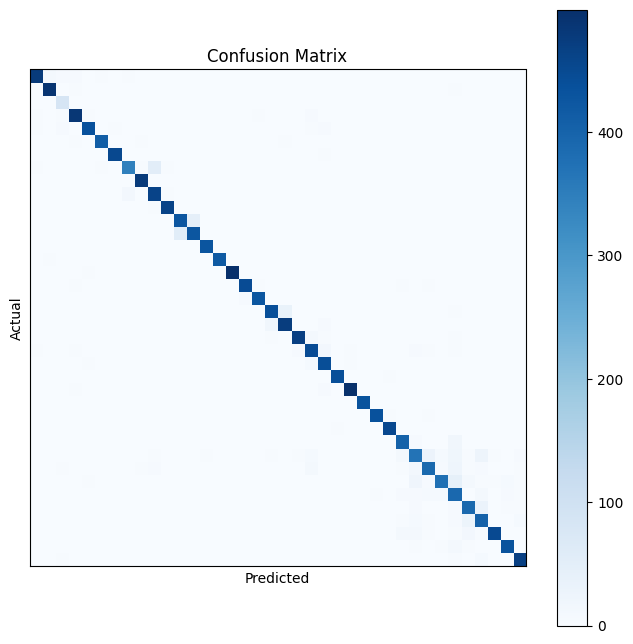

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(vgg_true, vgg_pred)

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([])
plt.yticks([])

plt.colorbar()

plt.show()

**31. Visualize Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step


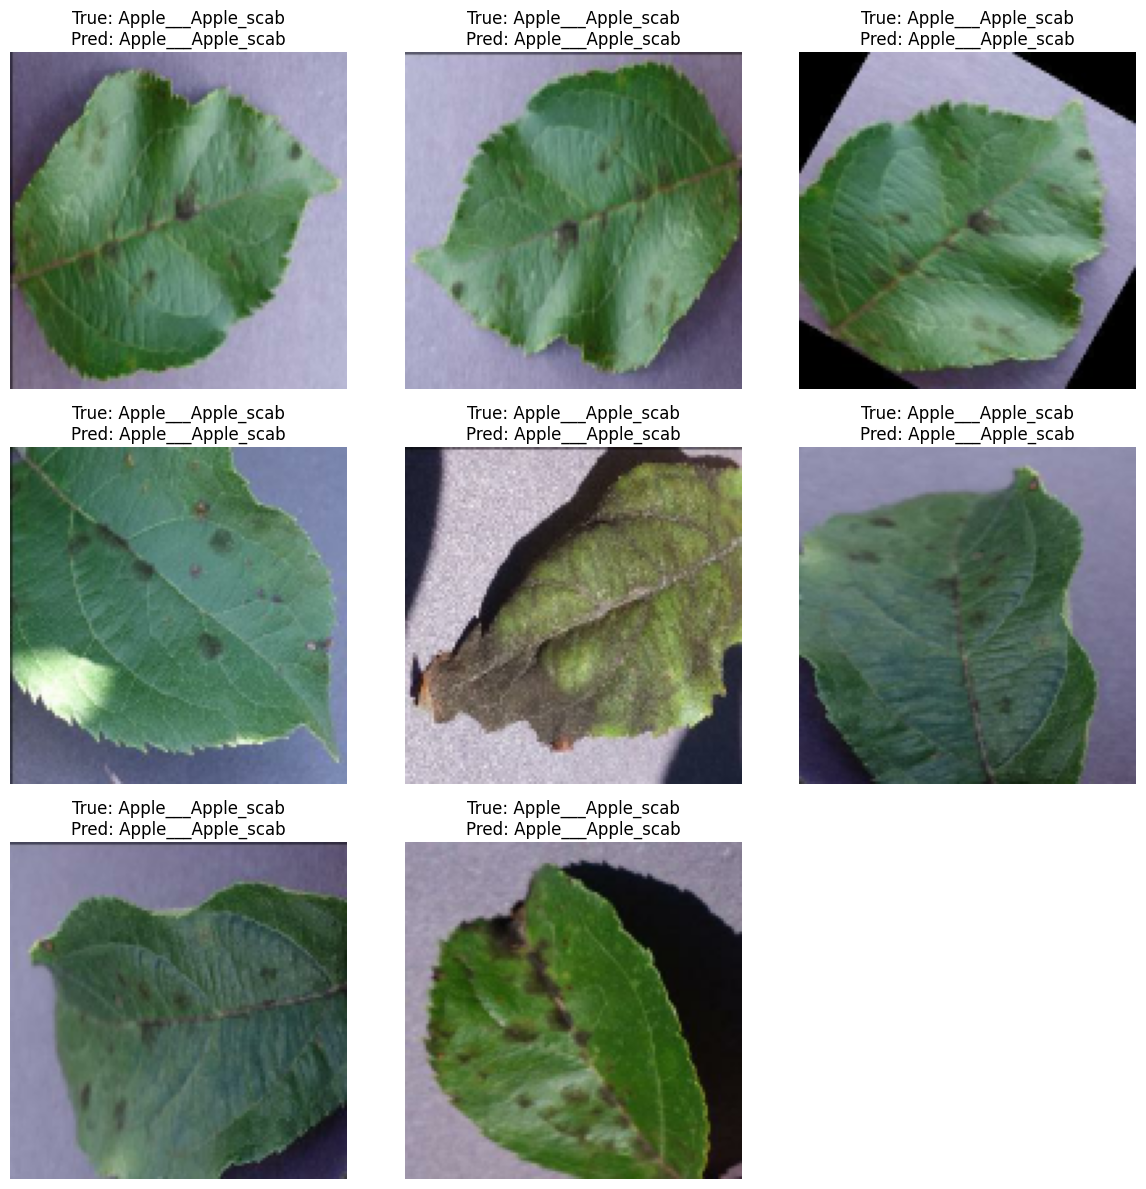

In [30]:
plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):

    predictions = vgg_model.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")

        plt.axis("off")

plt.tight_layout()
plt.show()

**32. Final Comparison Table**

In [31]:
results = pd.DataFrame({

    "Model": [
        "Baseline CNN",
        "Deep CNN",
        "VGG16"
    ],

    "Best Validation Accuracy": [

        max(history_baseline.history['val_accuracy']),

        max(history_deep.history['val_accuracy']),

        max(history_vgg.history['val_accuracy'])
    ],

    "Training Time (seconds)": [

        round(baseline_training_time, 2),

        round(deep_training_time, 2),

        round(vgg_training_time, 2)
    ]

})

results

,Model,Best Validation Accuracy,Training Time (seconds)
0,Baseline CNN,0.962703,574.87
1,Deep CNN,0.976266,933.02
2,VGG16,0.977527,2204.11


Final Model Evaluation

 Baseline Model

In [33]:
test_loss_baseline, test_acc_baseline = baseline_model.evaluate(test_ds) # Evaluate Baseline CNN

print("Baseline CNN Test Accuracy:", test_acc_baseline) # Display Baseline accuracy

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9537 - loss: 0.1434
Baseline CNN Test Accuracy: 0.953125


 Deep Model

In [34]:
test_loss_deep, test_acc_deep = deep_model.evaluate(test_ds) # Evaluate Deep CNN

print("Deep CNN Test Accuracy:", test_acc_deep) # Display Deep CNN accuracy

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9765 - loss: 0.0816
Deep CNN Test Accuracy: 0.964684009552002


VGG16 Model

In [35]:
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(test_ds) # Evaluate VGG16 model

print("VGG16 Test Accuracy:", test_acc_vgg) # Display VGG16 accuracy

2152/2152 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9564 - loss: 0.1246
VGG16 Test Accuracy: 0.9426115155220032


Comparison Table


In [36]:
# Comparison Table

results = pd.DataFrame({

    "Model": [

        "Baseline CNN",

        "Deep CNN",

        "VGG16"

    ],

    "Test Accuracy": [

        test_acc_baseline,

        test_acc_deep,

        test_acc_vgg

    ]

})

print(results) 

          Model  Test Accuracy
0  Baseline CNN       0.953125
1      Deep CNN       0.964684
2         VGG16       0.942612
